# 01 — Single-Architecture Comparator Model

**Purpose:** Trains one monolithic LightGBM model on the full engineered
feature set (88 predictors, no domain stratification). This model's
calibrated test performance is the "prior single-architecture model" row
in Table 5 of the accompanying manuscript, used as context for the
architecture-transfer comparison — it is not itself the primary analysis.

**What this notebook produces, in order:** cohort loading and deduplication
audit, feature engineering, Table 1 (cohort characteristics), case-mix
drift assessment, missing-data reporting, model training, Platt
calibration, bootstrap-CI performance, SHAP feature importance, decision
curve analysis, subgroup discrimination by ASA class/sex/age/procedure
type, stratified performance by vulnerability decile, and a floor-model
(ASA + age + Charlson) comparison with net reclassification improvement.

**Requires:** a local `df_model_1.csv` (not included; governed by an
institutional data use agreement).

**Temporal split:** Train ≤2018 | Validation 2019 (early stopping + Platt
calibration) | Test 2020 (held out for all reported performance).


## Imports, Path setup, and Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import lightgbm as lgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency

Path('artifacts').mkdir(exist_ok=True)

TARGET  = 'mort_30'
ID_COLS = ['study_id','study_enc_id','study_case_id']

# Load and deduplicate.
df = pd.read_csv('df_model_1.csv')
print(f'Loaded (pre-deduplication): {df.shape}')

# Verify deduplication does not drop death cases non-randomly.
_dup_mask = df.duplicated(subset=ID_COLS, keep=False)
_dups = df[_dup_mask].copy()
_other_cols = [c for c in _dups.columns if c not in ID_COLS]
_nuniq = _dups.groupby(ID_COLS)[_other_cols].nunique()
_cols_that_differ = list(_nuniq.columns[(_nuniq > 1).any(axis=0)])
_grp_mort = _dups.groupby(ID_COLS)[TARGET].agg(['nunique', 'sum'])
_n_conflicting = int((_grp_mort['nunique'] > 1).sum())
_n_groups = len(_grp_mort)
print(f'\nDeduplication audit: {_n_groups} duplicate groups found ({_dup_mask.sum()} rows).')
print(f'  Columns that ever differ between the two copies: {_cols_that_differ}')
print(f'  Groups where {TARGET} disagrees between copies: {_n_conflicting} (should be 0)')
if _n_conflicting > 0:
    raise RuntimeError(
        f"{_n_conflicting} duplicate group(s) have inconsistent {TARGET} values between "
        f"copies -- keep='first' may be dropping the copy with the recorded death. "
        f"Investigate before trusting mortality rate or any downstream metric.")
if _cols_that_differ not in ([], ['Unnamed: 0']):
    print(f"  NOTE: substantive columns differ between duplicate copies (not just the index "
          f"artifact) -- verify keep='first' picks the correct copy for: "
          f"{[c for c in _cols_that_differ if c != 'Unnamed: 0']}")
print(f"  PASS -- all {_n_groups} duplicate groups agree on {TARGET}; only {_cols_that_differ} "
      f"differs (a leftover index column, not real data).")

# Snapshot raw pre-imputation values for the missing-data report, before fillna() runs.
_raw_missingness_snapshot = df[['charlson_score', 'LR_plas_sodchlor_amt', 'albumin',
                                 'heta_hydro', 'true_year'] + ID_COLS].copy()

df = df.drop_duplicates(subset=ID_COLS, keep='first').copy()
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f'\nLoaded (post-deduplication): {df.shape} | Deaths: {int(df[TARGET].sum()):,} | {100*df[TARGET].mean():.2f}%')
print(f'Years:  {sorted(df["true_year"].unique())}')

# Pin library versions for reproducibility.
import sklearn
_version_table = pd.DataFrame([
    {'Library': 'lightgbm', 'Version': lgb.__version__},
    {'Library': 'shap', 'Version': shap.__version__},
    {'Library': 'scikit-learn', 'Version': sklearn.__version__},
    {'Library': 'pandas', 'Version': pd.__version__},
    {'Library': 'numpy', 'Version': np.__version__},
])
_version_table.to_csv('artifacts/Software_Versions.csv', index=False)
print('\nSoftware versions:')
display(_version_table)


Loaded (pre-deduplication): (388407, 84)

Deduplication audit: 522 duplicate groups found (1044 rows).
  Columns that ever differ between the two copies: ['Unnamed: 0']
  Groups where mort_30 disagrees between copies: 0 (should be 0)
  PASS -- all 522 duplicate groups agree on mort_30; only ['Unnamed: 0'] differs (a leftover index column, not real data).

Loaded (post-deduplication): (387885, 83) | Deaths: 5,272 | 1.36%
Years:  [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

Software versions:


,Library,Version
0,lightgbm,4.6.0
1,shap,0.49.1
2,scikit-learn,1.3.2
3,pandas,2.3.3
4,numpy,1.26.4


In [2]:
# Feature engineering.
vasopressor_cols = ['dobutamine','dopamine','ephedrine','epinephrine',
                    'milrinone','norepinephrine','phenylephrine','vasopressin']
antihtn_cols     = ['enalapril','esmolol','hydralazine','labetalol',
                    'metoprolol','propranolol','nicardipine','nitroprusside']
opioid_cols      = ['alfentanil','fentanyl','hydromorphone','meperidine',
                    'methadone','morphine','remifentanil','sufentanil']
nmba_cols        = ['atracurium','cisatracurium','mivacurium','pancuronium',
                    'rocuronium','succinylcholine','vecuronium']
sedative_cols    = ['diazepam','etomidate','ketamine','lorazepam','methohexital',
                    'midazolam','propofol','thiopental','dexmedetomidine']
comorb_cols      = ['anemia','ihd','ckd','copd','cancer','arrhyth','cvd',
                    'chr_dialysis','chr_etoh','HF','dementia','DM','aorta',
                    'drug_abuse','HVD','hemi_para','HTN','liver_dz','obesity',
                    'PVD','psych','pul_vasc','resp_fail','transplant']
all_drug_cols    = vasopressor_cols + antihtn_cols + opioid_cols + nmba_cols + sedative_cols

df['n_vasopressors']         = df[vasopressor_cols].sum(axis=1)
df['any_vasopressor']        = (df['n_vasopressors'] >= 1).astype(int)
df['n_antihypertensives']    = df[antihtn_cols].sum(axis=1)
df['n_opioids']              = df[opioid_cols].sum(axis=1)
df['n_nmba']                 = df[nmba_cols].sum(axis=1)
df['n_sedatives']            = df[sedative_cols].sum(axis=1)
df['n_total_drugs']          = df[all_drug_cols].sum(axis=1)
df['n_comorbidities']        = df[comorb_cols].sum(axis=1)
df['high_risk_comorbidity']  = (df[['HF','ckd','liver_dz','cancer','resp_fail',
                                    'chr_dialysis','dementia']].sum(axis=1)>=1).astype(int)
df['any_colloid']            = ((df['albumin']==1)|(df['heta_hydro']==1)).astype(int)
df['resuscitation_intensity']= df['blood_admin'] + df['any_colloid'] + df['any_vasopressor']
df['age_group']              = pd.cut(df['age_proc'],bins=[0,50,65,75,85,200],
                                      labels=['lt50','50_64','65_74','75_84','gte85'],
                                      right=False).astype(str)
df['prolonged_surgery']      = (df['proc_minutes'] > 240).astype(int)
df['log1p_fluid']            = np.log1p(df['LR_plas_sodchlor_amt'].fillna(0))
df['asa_x_age_high']         = ((pd.to_numeric(df['asa_class'],errors='coerce') >= 4) &
                                 (df['age_proc'] >= 75)).astype(int)
df['high_acuity']            = ((df['n_vasopressors']>=2)&(df['proc_minutes']>180)).astype(int)
df['race_cat']               = df['race_eth'].fillna('Unknown').astype(str)
df['charlson_score']         = df['charlson_score'].fillna(df['charlson_score'].median())
df['LR_plas_sodchlor_amt']   = df['LR_plas_sodchlor_amt'].fillna(0)
df['albumin']                = df['albumin'].fillna(0)
df['heta_hydro']             = df['heta_hydro'].fillna(0)

# Feature set.
CAT_COLS = ['SEX', 'age_group', 'asa_class', 'proc_type', 'race_cat']

# LR_plas_sodchlor_amt / log1p_fluid excluded as predictors: SMD=1.70 train-vs-test drift,
# tied to a documentation/extraction change rather than a physiologic trend, and removing
# them changes AUROC by <0.001. Kept in `df` for the drift report below, not fed to the model.
CONT_COLS = ['true_year','age_proc','proc_minutes','total_mac_hrs',
             'charlson_score',
             'n_vasopressors','n_antihypertensives','n_nmba','n_opioids',
             'n_sedatives','n_total_drugs','resuscitation_intensity']
BINARY_COLS = [c for c in df.columns
               if c not in CONT_COLS + CAT_COLS + ID_COLS + [TARGET, 'RACE', 'race_eth',
                  'LR_plas_sodchlor_amt']
               and df[c].dtype in [np.int64, np.int32]
               and set(df[c].dropna().unique()).issubset({0,1})
               and df[c].nunique() > 1]

le_dict = {}
for c in CAT_COLS:
    if c in df.columns:
        df[c] = df[c].fillna('Unknown').astype(str)
        le = LabelEncoder()
        df[c+'_enc'] = le.fit_transform(df[c])
        le_dict[c] = le

FINAL_FEAT = CONT_COLS + [c+'_enc' for c in CAT_COLS if c+'_enc' in df.columns] + BINARY_COLS
FINAL_FEAT = [c for c in FINAL_FEAT if c in df.columns and df[c].nunique() > 1]
CAT_INDICES = [FINAL_FEAT.index(c+'_enc') for c in CAT_COLS if c+'_enc' in FINAL_FEAT]

print(f'Features: {len(FINAL_FEAT)} | Categorical indices: {CAT_INDICES}')


Features: 88 | Categorical indices: [12, 13, 14, 15, 16]


## Helper Functions
Bootstrap and table-building utilities, used throughout. Patient-level bootstrap resamples by `study_id`, not by row, since some patients contribute more than one encounter.

In [3]:
def bootstrap_performance(y, p, id_values, n_boot=1000, seed=42, alpha=0.05):
    """Patient-level bootstrap CI for AUROC, PR-AUC, Brier."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y); p = np.asarray(p); ids = np.asarray(id_values)
    id_to_idx = {}
    for i, uid in enumerate(ids):
        id_to_idx.setdefault(uid, []).append(i)
    uniq_ids = np.array(list(id_to_idx.keys()))
    aurocs, praucs, briers = [], [], []
    for _ in range(n_boot):
        samp_ids = rng.choice(uniq_ids, size=len(uniq_ids), replace=True)
        idx = np.concatenate([id_to_idx[i] for i in samp_ids])
        yb, pb = y[idx], p[idx]
        if len(np.unique(yb)) < 2:
            continue
        aurocs.append(roc_auc_score(yb, pb))
        praucs.append(average_precision_score(yb, pb))
        briers.append(brier_score_loss(yb, pb))

    def _ci(arr):
        arr = np.array(arr)
        return (float(np.mean(arr)),
                float(np.percentile(arr, 100*alpha/2)),
                float(np.percentile(arr, 100*(1-alpha/2))))

    a_mean, a_lo, a_hi = _ci(aurocs)
    p_mean, p_lo, p_hi = _ci(praucs)
    b_mean, b_lo, b_hi = _ci(briers)
    return {
        'AUROC boot mean': a_mean, 'AUROC CI low': a_lo, 'AUROC CI high': a_hi,
        'PR-AUC boot mean': p_mean, 'PR-AUC CI low': p_lo, 'PR-AUC CI high': p_hi,
        'Brier boot mean': b_mean, 'Brier CI low': b_lo, 'Brier CI high': b_hi,
        'N bootstrap resamples used': len(aurocs)
    }


def bootstrap_net_benefit(y_true, p_pred, thresholds, id_values, n_boot=500, seed=42, alpha=0.05):
    """Patient-level bootstrap CI for decision-curve net benefit at fixed thresholds."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y_true, dtype=float); p = np.asarray(p_pred, dtype=float)
    ids = np.asarray(id_values)
    id_to_idx = {}
    for i, uid in enumerate(ids):
        id_to_idx.setdefault(uid, []).append(i)
    uniq_ids = np.array(list(id_to_idx.keys()))
    boot_nb = {t: [] for t in thresholds}
    for _ in range(n_boot):
        samp_ids = rng.choice(uniq_ids, size=len(uniq_ids), replace=True)
        idx = np.concatenate([id_to_idx[i] for i in samp_ids])
        yb, pb = y[idx], p[idx]
        n = len(yb)
        for t in thresholds:
            tp = ((pb >= t) & (yb == 1)).sum()
            fp = ((pb >= t) & (yb == 0)).sum()
            boot_nb[t].append((tp/n) - (fp/n) * (t/(1-t)))
    rows = []
    for t in thresholds:
        arr = np.array(boot_nb[t])
        rows.append({'Threshold (%)': round(t*100, 1),
                     'NB mean': float(np.mean(arr)),
                     'NB CI low': float(np.percentile(arr, 100*alpha/2)),
                     'NB CI high': float(np.percentile(arr, 100*(1-alpha/2)))})
    return pd.DataFrame(rows)


def net_reclassification_improvement(y_true, p_old, p_new, thresholds=(0.01, 0.05)):
    """Categorical net reclassification improvement using fixed risk thresholds."""
    y = np.asarray(y_true).astype(int)
    edges = [-np.inf] + list(thresholds) + [np.inf]
    b_old = np.digitize(np.asarray(p_old), edges) - 1
    b_new = np.digitize(np.asarray(p_new), edges) - 1
    up, down = (b_new > b_old), (b_new < b_old)
    events, nonevents = (y == 1), (y == 0)
    n_ev, n_nonev = events.sum(), nonevents.sum()
    nri_ev    = (up[events].sum()    - down[events].sum())    / n_ev    if n_ev    > 0 else np.nan
    nri_nonev = (down[nonevents].sum() - up[nonevents].sum())  / n_nonev if n_nonev > 0 else np.nan
    return {'NRI events': nri_ev, 'NRI nonevents': nri_nonev,
            'NRI total': nri_ev + nri_nonev if pd.notna(nri_ev) and pd.notna(nri_nonev) else np.nan,
            'N events': int(n_ev), 'N nonevents': int(n_nonev)}


def _t1_cont(df, var, group_col=None):
    x = pd.to_numeric(df[var], errors='coerce').dropna()
    row = {'Variable': var, 'Type': 'Continuous',
           'Overall median [IQR]': f"{x.median():.2f} [{x.quantile(.25):.2f}-{x.quantile(.75):.2f}]",
           'Overall N': int(x.notna().sum())}
    if group_col is not None:
        groups = list(df[group_col].dropna().unique())
        for g in groups:
            xg = pd.to_numeric(df.loc[df[group_col] == g, var], errors='coerce').dropna()
            row[f'{g} median [IQR]'] = (f"{xg.median():.2f} [{xg.quantile(.25):.2f}-{xg.quantile(.75):.2f}]"
                                         if len(xg) > 0 else 'NA')
        if len(groups) == 2:
            x1 = pd.to_numeric(df.loc[df[group_col] == groups[0], var], errors='coerce').dropna()
            x2 = pd.to_numeric(df.loc[df[group_col] == groups[1], var], errors='coerce').dropna()
            try:
                _, p = mannwhitneyu(x1, x2)
                row['P value'] = p
            except Exception:
                row['P value'] = np.nan
        elif len(groups) > 2:
            arrs = [pd.to_numeric(df.loc[df[group_col] == g, var], errors='coerce').dropna() for g in groups]
            try:
                _, p = kruskal(*arrs)
                row['P value'] = p
            except Exception:
                row['P value'] = np.nan
    return row


def _t1_cat(df, var, group_col=None):
    s = df[var].astype(str)
    n_total = s.notna().sum()
    vc = s.value_counts(dropna=True)
    rows = []
    for level, n in vc.items():
        row = {'Variable': f'{var} = {level}', 'Type': 'Categorical',
               'Overall n (%)': f'{n} ({100*n/n_total:.1f}%)'}
        if group_col is not None:
            for g in df[group_col].dropna().unique():
                sub = s[df[group_col] == g]
                ng, tot_g = (sub == level).sum(), sub.notna().sum()
                row[f'{g} n (%)'] = f'{ng} ({100*ng/tot_g:.1f}%)' if tot_g > 0 else 'NA'
        rows.append(row)
    if group_col is not None and len(rows) > 0:
        try:
            ct = pd.crosstab(df[var].astype(str), df[group_col])
            _, p, _, _ = chi2_contingency(ct)
        except Exception:
            p = np.nan
        for row in rows:
            row['P value'] = p
    return rows


def build_table1(df, cont_vars, cat_vars, group_col=None):
    rows = []
    for v in cont_vars:
        if v in df.columns:
            rows.append(_t1_cont(df, v, group_col))
    for v in cat_vars:
        if v in df.columns:
            rows.extend(_t1_cat(df, v, group_col))
    return pd.DataFrame(rows)


def missing_data_report(df, feature_list):
    n = len(df)
    rows = [{'Variable': v, 'N missing': int(df[v].isna().sum()),
             'Percent missing': round(100 * df[v].isna().sum() / n, 3)}
            for v in feature_list if v in df.columns]
    return pd.DataFrame(rows).sort_values('Percent missing', ascending=False)


def smd_continuous(x1, x2):
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    x2 = pd.to_numeric(x2, errors='coerce').dropna()
    if len(x1) == 0 or len(x2) == 0:
        return np.nan
    pooled_sd = np.sqrt((x1.var(ddof=1) + x2.var(ddof=1)) / 2)
    if not np.isfinite(pooled_sd) or pooled_sd == 0:
        return np.nan
    return float((x1.mean() - x2.mean()) / pooled_sd)


def smd_binary(x1, x2):
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    x2 = pd.to_numeric(x2, errors='coerce').dropna()
    p1, p2 = x1.mean(), x2.mean()
    pooled = (p1 * (1 - p1) + p2 * (1 - p2)) / 2
    if pooled <= 0:
        return np.nan
    return float((p1 - p2) / np.sqrt(pooled))


def case_mix_drift_table(df_a, df_b, cont_vars, bin_vars, label_a, label_b, threshold=0.10):
    rows = []
    for v in cont_vars:
        if v in df_a.columns and v in df_b.columns:
            smd = smd_continuous(df_a[v], df_b[v])
            rows.append({'Variable': v, 'Type': 'Continuous', 'SMD': smd,
                         'Flag |SMD|>0.10': (abs(smd) > threshold) if pd.notna(smd) else np.nan})
    for v in bin_vars:
        if v in df_a.columns and v in df_b.columns:
            smd = smd_binary(df_a[v], df_b[v])
            rows.append({'Variable': v, 'Type': 'Binary', 'SMD': smd,
                         'Flag |SMD|>0.10': (abs(smd) > threshold) if pd.notna(smd) else np.nan})
    out = pd.DataFrame(rows).sort_values('SMD', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
    out.attrs['comparison'] = f'{label_a} vs {label_b}'
    return out


print('Helper functions ready.')


Helper functions ready.


## Step 1 — Temporal Split

In [4]:
train_df = df[df['true_year'] <= 2018].copy()
val_df   = df[df['true_year'] == 2019].copy()
test_df  = df[df['true_year'] == 2020].copy()

for name, part in [('Train <=2018',train_df),('Val  2019',val_df),('Test 2020',test_df)]:
    print(f'{name}: N={len(part):>7,} | Deaths={int(part[TARGET].sum()):>5} | {100*part[TARGET].mean():.3f}%')

X_train = train_df[FINAL_FEAT].astype(float)
y_train = train_df[TARGET].astype(int)
X_val   = val_df[FINAL_FEAT].astype(float)
y_val   = val_df[TARGET].astype(int)
X_test  = test_df[FINAL_FEAT].astype(float)
y_test  = test_df[TARGET].astype(int)

scale_pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
print(f'\nscale_pos_weight: {scale_pos_weight:.2f}')

# Verify no patient appears in more than one temporal split.
_ids_train, _ids_val, _ids_test = set(train_df['study_id']), set(val_df['study_id']), set(test_df['study_id'])
print('No train/test overlap:', len(_ids_train & _ids_test) == 0)
print('No train/val overlap: ', len(_ids_train & _ids_val)  == 0,
      f'' if len(_ids_train & _ids_val)==0 else f'({len(_ids_train & _ids_val)} shared study_id)')
print('No val/test overlap:  ', len(_ids_val & _ids_test)   == 0,
      f'' if len(_ids_val & _ids_test)==0 else f'({len(_ids_val & _ids_test)} shared study_id)')


Train <=2018: N=278,514 | Deaths= 4105 | 1.474%
Val  2019: N= 52,117 | Deaths=  497 | 0.954%
Test 2020: N= 57,254 | Deaths=  670 | 1.170%

scale_pos_weight: 66.85
No train/test overlap: True
No train/val overlap:  True 
No val/test overlap:   True 


### Table 1 — Cohort Characteristics
Overall, by cohort (Train/Val/Test), and by 30-day vital status.

In [5]:
T1_CONT = ['age_proc','proc_minutes','total_mac_hrs','charlson_score',
           'n_comorbidities','n_total_drugs','resuscitation_intensity']
T1_CAT  = ['SEX','asa_class','age_group','proc_type','race_cat']

full_with_cohort = df.copy()
full_with_cohort['cohort'] = np.select(
    [full_with_cohort['true_year'] <= 2018,
     full_with_cohort['true_year'] == 2019,
     full_with_cohort['true_year'] == 2020],
    ['Train (<=2018)', 'Validation (2019)', 'Test (2020)'], default='Other')

table1_overall    = build_table1(full_with_cohort, T1_CONT, T1_CAT, group_col=None)
table1_by_cohort  = build_table1(full_with_cohort, T1_CONT, T1_CAT, group_col='cohort')
table1_by_outcome = build_table1(full_with_cohort, T1_CONT, T1_CAT, group_col=TARGET)

table1_overall.to_csv('artifacts/Table1_Overall.csv', index=False)
table1_by_cohort.to_csv('artifacts/Table1_ByCohort.csv', index=False)
table1_by_outcome.to_csv('artifacts/Table1_ByVitalStatus.csv', index=False)

print('Table 1 — overall:')
display(table1_overall.head(10))
print('\nTable 1 — by cohort (Train/Val/Test):')
display(table1_by_cohort.head(10))


Table 1 — overall:


,Variable,Type,Overall median [IQR],Overall N,Overall n (%)
0,age_proc,Continuous,56.27 [41.13-68.26],387885.0,NaN
1,proc_minutes,Continuous,60.00 [35.00-104.00],387885.0,NaN
2,total_mac_hrs,Continuous,1.08 [0.08-2.01],387885.0,NaN
3,charlson_score,Continuous,0.00 [0.00-1.00],387885.0,NaN
4,n_comorbidities,Continuous,0.00 [0.00-0.00],387885.0,NaN
5,n_total_drugs,Continuous,4.00 [3.00-5.00],387885.0,NaN
6,resuscitation_intensity,Continuous,0.00 [0.00-1.00],387885.0,NaN
7,SEX = F,Categorical,NaN,NaN,210994 (54.4%)
8,SEX = M,Categorical,NaN,NaN,176601 (45.5%)
9,SEX = Unknown,Categorical,NaN,NaN,290 (0.1%)



Table 1 — by cohort (Train/Val/Test):


,Variable,Type,Overall median [IQR],Overall N,Validation (2019) median [IQR],Train (<=2018) median [IQR],Test (2020) median [IQR],P value,Overall n (%),Validation (2019) n (%),Train (<=2018) n (%),Test (2020) n (%)
0,age_proc,Continuous,56.27 [41.13-68.26],387885.0,58.51 [43.87-69.41],55.26 [40.08-67.70],58.99 [44.58-69.42],0.000000e+00,NaN,NaN,NaN,NaN
1,proc_minutes,Continuous,60.00 [35.00-104.00],387885.0,55.00 [32.00-96.00],62.00 [36.00-106.00],56.00 [32.00-100.00],5.360437e-297,NaN,NaN,NaN,NaN
2,total_mac_hrs,Continuous,1.08 [0.08-2.01],387885.0,0.99 [0.00-1.88],1.11 [0.38-2.04],1.01 [0.00-1.95],1.538962e-228,NaN,NaN,NaN,NaN
3,charlson_score,Continuous,0.00 [0.00-1.00],387885.0,0.00 [0.00-2.00],0.00 [0.00-1.00],0.00 [0.00-2.00],0.000000e+00,NaN,NaN,NaN,NaN
4,n_comorbidities,Continuous,0.00 [0.00-0.00],387885.0,0.00 [0.00-0.00],0.00 [0.00-0.00],0.00 [0.00-0.00],3.002437e-34,NaN,NaN,NaN,NaN
5,n_total_drugs,Continuous,4.00 [3.00-5.00],387885.0,4.00 [2.00-5.00],4.00 [3.00-5.00],4.00 [2.00-5.00],0.000000e+00,NaN,NaN,NaN,NaN
6,resuscitation_intensity,Continuous,0.00 [0.00-1.00],387885.0,0.00 [0.00-1.00],0.00 [0.00-1.00],0.00 [0.00-1.00],1.402671e-02,NaN,NaN,NaN,NaN
7,SEX = F,Categorical,NaN,NaN,NaN,NaN,NaN,1.910633e-04,210994 (54.4%),28544 (54.8%),151474 (54.4%),30976 (54.1%)
8,SEX = M,Categorical,NaN,NaN,NaN,NaN,NaN,1.910633e-04,176601 (45.5%),23537 (45.2%),126805 (45.5%),26259 (45.9%)
9,SEX = Unknown,Categorical,NaN,NaN,NaN,NaN,NaN,1.910633e-04,290 (0.1%),36 (0.1%),235 (0.1%),19 (0.0%)


### Case-Mix Drift Table
Train vs. Test as primary comparison; Train vs. Val shown since Val drives Platt calibration. Flags |SMD| > 0.10. `true_year` is excluded from the continuous-variable list since it defines the cohort split.

In [6]:
CONT_COLS_DRIFT = [c for c in CONT_COLS if c != 'true_year']  # excludes the split-defining variable

case_mix_drift_train_vs_test = case_mix_drift_table(
    train_df, test_df, CONT_COLS_DRIFT, BINARY_COLS, 'Train (<=2018)', 'Test (2020)')
case_mix_drift_train_vs_val = case_mix_drift_table(
    train_df, val_df, CONT_COLS_DRIFT, BINARY_COLS, 'Train (<=2018)', 'Validation (2019)')

case_mix_drift_train_vs_test.to_csv('artifacts/CaseMixDrift_Train_vs_Test.csv', index=False)
case_mix_drift_train_vs_val.to_csv('artifacts/CaseMixDrift_Train_vs_Val.csv', index=False)

n_flagged_test = int(case_mix_drift_train_vs_test['Flag |SMD|>0.10'].fillna(False).sum())
n_flagged_val  = int(case_mix_drift_train_vs_val['Flag |SMD|>0.10'].fillna(False).sum())
print(f'Train vs Test: {n_flagged_test} / {len(case_mix_drift_train_vs_test)} variables with |SMD| > 0.10')
print(f'Train vs Val:  {n_flagged_val} / {len(case_mix_drift_train_vs_val)} variables with |SMD| > 0.10')
display(case_mix_drift_train_vs_test.head(15))

# Diagnostic: percent-zero shift for the top-drift continuous variable's source column
for _v in ['LR_plas_sodchlor_amt']:
    if _v in train_df.columns and _v in test_df.columns:
        _x1 = pd.to_numeric(train_df[_v], errors='coerce')
        _x2 = pd.to_numeric(test_df[_v], errors='coerce')
        print(f"\n{_v}: Train pct_zero={100*(_x1==0).mean():.1f}% (median={_x1.median():.0f}) "
              f"vs Test pct_zero={100*(_x2==0).mean():.1f}% (median={_x2.median():.0f})")


Train vs Test: 16 / 82 variables with |SMD| > 0.10
Train vs Val:  15 / 82 variables with |SMD| > 0.10


,Variable,Type,SMD,Flag |SMD|>0.10
0,cisatracurium,Binary,0.397209,True
1,any_colloid,Binary,0.263261,True
2,midazolam,Binary,0.251382,True
3,n_nmba,Continuous,0.243398,True
4,charlson_score,Continuous,-0.191654,True
5,n_total_drugs,Continuous,0.190878,True
6,succinylcholine,Binary,0.179110,True
7,morphine,Binary,0.166116,True
8,metoprolol,Binary,0.159376,True
9,ketamine,Binary,-0.157256,True



LR_plas_sodchlor_amt: Train pct_zero=14.5% (median=900) vs Test pct_zero=79.0% (median=0)


### Missing-Data Report
Reports missingness computed before imputation for variables that are later filled, and after standard processing for everything else.

In [7]:
missing_data_report_table = missing_data_report(train_df, FINAL_FEAT)

_raw_train_snapshot = _raw_missingness_snapshot[_raw_missingness_snapshot['true_year'] <= 2018]
_imputed_vars_report = missing_data_report(
    _raw_train_snapshot, ['charlson_score', 'LR_plas_sodchlor_amt', 'albumin', 'heta_hydro'])
_imputed_vars_report['Variable'] = _imputed_vars_report['Variable'] + ' (pre-imputation, raw)'

missing_data_report_table = pd.concat([missing_data_report_table, _imputed_vars_report], ignore_index=True) \
    .sort_values('Percent missing', ascending=False)
missing_data_report_table.to_csv('artifacts/Missing_Data_Report.csv', index=False)
print('Missing-data report (train_df, sorted by % missing; imputed variables shown pre-imputation):')
display(missing_data_report_table.head(15))

cohort_flow_table = pd.DataFrame([
    {'Stage': 'Loaded (post-deduplication)', 'N': len(df),
     'Note': 'Pre-dedup N not printed in original code — see notebook header note.'},
    {'Stage': 'Train (<=2018)', 'N': len(train_df), 'Note': ''},
    {'Stage': 'Validation (2019)', 'N': len(val_df), 'Note': 'Used for early stopping + Platt calibration'},
    {'Stage': 'Test (2020)', 'N': len(test_df), 'Note': 'Held out for all reported performance'},
])
cohort_flow_table.to_csv('artifacts/Cohort_Flow.csv', index=False)
print('\nCohort flow:')
display(cohort_flow_table)


Missing-data report (train_df, sorted by % missing; imputed variables shown pre-imputation):


,Variable,N missing,Percent missing
88,"charlson_score (pre-imputation, raw)",72528,25.995
91,"heta_hydro (pre-imputation, raw)",2017,0.723
90,"albumin (pre-imputation, raw)",2017,0.723
89,"LR_plas_sodchlor_amt (pre-imputation, raw)",2017,0.723
57,n_sedatives,0,0.000
65,epinephrine,0,0.000
64,proc_minutes,0,0.000
63,total_mac_hrs,0,0.000
62,charlson_score,0,0.000
61,n_vasopressors,0,0.000



Cohort flow:


,Stage,N,Note
0,Loaded (post-deduplication),387885,Pre-dedup N not printed in original code — see...
1,Train (<=2018),278514,
2,Validation (2019),52117,Used for early stopping + Platt calibration
3,Test (2020),57254,Held out for all reported performance


## Step 2 — Train LightGBM

In [8]:
lgb_train = lgb.Dataset(X_train, label=y_train,
                         categorical_feature=CAT_INDICES, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val,   label=y_val,
                         categorical_feature=CAT_INDICES, free_raw_data=False)

params = {
    'objective':'binary', 'metric':'average_precision', 'boosting_type':'gbdt',
    'learning_rate':0.03, 'num_leaves':63, 'max_depth':-1,
    'min_child_samples':100, 'subsample':0.8, 'colsample_bytree':0.8,
    'reg_lambda':1.0, 'scale_pos_weight':scale_pos_weight,
    'random_state':42, 'n_jobs':-1, 'verbose':-1
}

callbacks = [lgb.early_stopping(100, verbose=True), lgb.log_evaluation(100)]
model = lgb.train(params, lgb_train, num_boost_round=5000,
                  valid_sets=[lgb_val], callbacks=callbacks)

model.save_model('artifacts/lgbm_final.txt')
print('\nModel saved.')

# Raw predictions
p_train_raw = model.predict(X_train)
p_val_raw   = model.predict(X_val)
p_test_raw  = model.predict(X_test)
print(f'Raw test predictions: min={p_test_raw.min():.4f} max={p_test_raw.max():.4f} mean={p_test_raw.mean():.4f}')


Training until validation scores don't improve for 100 rounds
[100]	valid_0's average_precision: 0.234921
[200]	valid_0's average_precision: 0.264981
[300]	valid_0's average_precision: 0.263365
Early stopping, best iteration is:
[242]	valid_0's average_precision: 0.266951

Model saved.
Raw test predictions: min=0.0004 max=0.9935 mean=0.1821


### Hyperparameter Table

In [9]:
hyperparam_rows = [{'Parameter': k, 'Value': v} for k, v in params.items()]
hyperparam_rows += [
    {'Parameter': 'num_boost_round (max)', 'Value': 5000},
    {'Parameter': 'early_stopping_rounds', 'Value': 100},
    {'Parameter': 'Early-stopping metric', 'Value': 'PR-AUC (validation 2019)'},
    {'Parameter': 'Best iteration', 'Value': int(model.best_iteration)},
]
hyperparam_table = pd.DataFrame(hyperparam_rows)
hyperparam_table.to_csv('artifacts/LightGBM_Hyperparameters.csv', index=False)
print('LightGBM hyperparameter configuration:')
display(hyperparam_table)


LightGBM hyperparameter configuration:


,Parameter,Value
0,objective,binary
1,metric,average_precision
2,boosting_type,gbdt
3,learning_rate,0.03
4,num_leaves,63
5,max_depth,-1
6,min_child_samples,100
7,subsample,0.8
8,colsample_bytree,0.8
9,reg_lambda,1.0


## Step 3 — Platt Scaling Calibration
Fit on validation 2019, applied to test 2020.

In [10]:
def logit(p, eps=1e-7):
    p = np.clip(p, eps, 1-eps)
    return np.log(p / (1 - p))

# Fit Platt scaler on validation set (2019)
logit_val  = logit(p_val_raw).reshape(-1, 1)
platt = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
platt.fit(logit_val, y_val)

# Apply to all sets
p_val_cal   = platt.predict_proba(logit(p_val_raw).reshape(-1,1))[:,1]
p_test_cal  = platt.predict_proba(logit(p_test_raw).reshape(-1,1))[:,1]
p_train_cal = platt.predict_proba(logit(p_train_raw).reshape(-1,1))[:,1]

joblib.dump(platt, 'artifacts/platt_scaler.joblib')
print('Platt scaler fitted and saved.')
print(f'\nCalibrated test predictions:')
print(f'  min={p_test_cal.min():.4f} max={p_test_cal.max():.4f} mean={p_test_cal.mean():.4f}')
print(f'  Observed mortality test 2020: {y_test.mean():.4f}')
print(f'  Mean raw predicted:  {p_test_raw.mean():.4f}')
print(f'  Mean calibrated:     {p_test_cal.mean():.4f}  <- should be close to observed')


Platt scaler fitted and saved.

Calibrated test predictions:
  min=0.0000 max=0.7307 mean=0.0107
  Observed mortality test 2020: 0.0117
  Mean raw predicted:  0.1821
  Mean calibrated:     0.0107  <- should be close to observed


## Step 4 — Temporal Validation Performance (Raw vs. Calibrated)

In [11]:
def cal_slope_intercept(y, p):
    try:
        from sklearn.linear_model import LinearRegression
        pt, pp = calibration_curve(y, p, n_bins=10, strategy='quantile')
        slope, intercept = np.polyfit(pp, pt, 1)
        return round(float(intercept), 4), round(float(slope), 4)
    except:
        return np.nan, np.nan

def metrics(y, p, label):
    auroc = roc_auc_score(y, p)
    prauc = average_precision_score(y, p)
    brier = brier_score_loss(y, p)
    ci, cs = cal_slope_intercept(y, p)
    return {'Model':label, 'N':len(y), 'Deaths':int(y.sum()),
            'AUROC':round(auroc,4), 'PR-AUC':round(prauc,4),
            'Brier':round(brier,4), 'Cal intercept':ci, 'Cal slope':cs}

rows = [
    metrics(y_val,  p_val_raw,  'Val 2019 - Raw'),
    metrics(y_val,  p_val_cal,  'Val 2019 - Calibrated'),
    metrics(y_test, p_test_raw, 'Test 2020 - Raw'),
    metrics(y_test, p_test_cal, 'Test 2020 - Calibrated'),
]
perf_table = pd.DataFrame(rows)
print('-- Performance: Raw vs Calibrated --')
display(perf_table)
perf_table.to_csv('artifacts/performance_raw_vs_calibrated.csv', index=False)

# Save test predictions
preds_df = test_df[ID_COLS+[TARGET,'true_year']].copy()
preds_df['p_raw']        = p_test_raw
preds_df['p_calibrated'] = p_test_cal
preds_df.to_parquet('artifacts/test_predictions_2020.parquet', index=False)
print('\nSaved -> artifacts/performance_raw_vs_calibrated.csv')


-- Performance: Raw vs Calibrated --


,Model,N,Deaths,AUROC,PR-AUC,Brier,Cal intercept,Cal slope
0,Val 2019 - Raw,52117,497,0.9336,0.2670,0.0829,-0.0044,0.0839
1,Val 2019 - Calibrated,52117,497,0.9336,0.2670,0.0080,-0.0000,1.0030
2,Test 2020 - Raw,57254,670,0.9225,0.2654,0.0921,-0.0050,0.0916
3,Test 2020 - Calibrated,57254,670,0.9225,0.2654,0.0099,0.0008,1.0172



Saved -> artifacts/performance_raw_vs_calibrated.csv


### Bootstrap CIs for Step 4
Patient-level bootstrap, 1,000 resamples.

In [12]:
bootstrap_ci_rows = []
for label, ydat, pdat, iddat in [
    ('Val 2019 - Raw',        y_val,  p_val_raw,  val_df['study_id'].values),
    ('Val 2019 - Calibrated', y_val,  p_val_cal,  val_df['study_id'].values),
    ('Test 2020 - Raw',       y_test, p_test_raw, test_df['study_id'].values),
    ('Test 2020 - Calibrated',y_test, p_test_cal, test_df['study_id'].values),
]:
    res = bootstrap_performance(ydat.values, pdat, iddat, n_boot=1000)
    res['Model'] = label
    bootstrap_ci_rows.append(res)

perf_table_bootstrap = pd.DataFrame(bootstrap_ci_rows)[
    ['Model','AUROC boot mean','AUROC CI low','AUROC CI high',
     'PR-AUC boot mean','PR-AUC CI low','PR-AUC CI high',
     'Brier boot mean','Brier CI low','Brier CI high','N bootstrap resamples used']]
perf_table_bootstrap.to_csv('artifacts/Performance_Bootstrap_CI.csv', index=False)
print('Performance with 95% bootstrap CIs (patient-level, 1000 resamples):')
display(perf_table_bootstrap.round(4))


Performance with 95% bootstrap CIs (patient-level, 1000 resamples):


,Model,AUROC boot mean,AUROC CI low,AUROC CI high,PR-AUC boot mean,PR-AUC CI low,PR-AUC CI high,Brier boot mean,Brier CI low,Brier CI high,N bootstrap resamples used
0,Val 2019 - Raw,0.9332,0.9226,0.9432,0.2679,0.2274,0.309,0.0829,0.0813,0.0845,1000
1,Val 2019 - Calibrated,0.9332,0.9226,0.9432,0.2679,0.2274,0.309,0.0080,0.0074,0.0087,1000
2,Test 2020 - Raw,0.9228,0.9128,0.9322,0.2669,0.2331,0.301,0.0920,0.0905,0.0935,1000
3,Test 2020 - Calibrated,0.9228,0.9128,0.9322,0.2669,0.2331,0.301,0.0099,0.0092,0.0106,1000


## Step 5 — Calibration Curves (Before and After Platt Scaling)

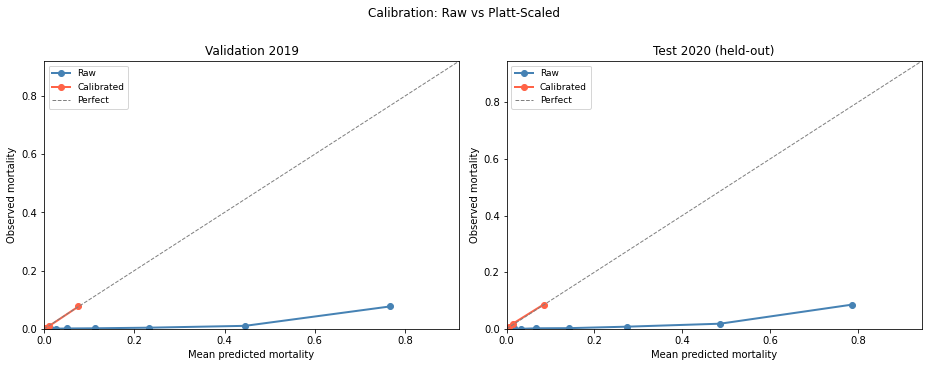

Saved -> artifacts/calibration_before_after.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title, pairs in zip(axes,
    ['Validation 2019', 'Test 2020 (held-out)'],
    [[(y_val, p_val_raw, 'Raw', 'steelblue'),
      (y_val, p_val_cal, 'Calibrated', 'tomato')],
     [(y_test, p_test_raw, 'Raw', 'steelblue'),
      (y_test, p_test_cal, 'Calibrated', 'tomato')]]):

    ax_max = 0
    for y_, p_, lbl, col in pairs:
        pt, pp = calibration_curve(y_, p_, n_bins=10, strategy='quantile')
        ax.plot(pp, pt, 'o-', color=col, linewidth=2, label=lbl)
        ax_max = max(ax_max, float(pp.max()), float(pt.max()))

    ax_max = min(ax_max * 1.2, 1.0)
    ax.plot([0,ax_max],[0,ax_max],'--',color='gray',linewidth=1,label='Perfect')
    ax.set_xlim(0,ax_max); ax.set_ylim(0,ax_max)
    ax.set_xlabel('Mean predicted mortality')
    ax.set_ylabel('Observed mortality')
    ax.set_title(title); ax.legend(fontsize=9)

plt.suptitle("Calibration: Raw vs Platt-Scaled", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('artifacts/calibration_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> artifacts/calibration_before_after.png')


## Step 6 — SHAP Feature Importance
Model fit on training data only, applied to a sample of the test set.

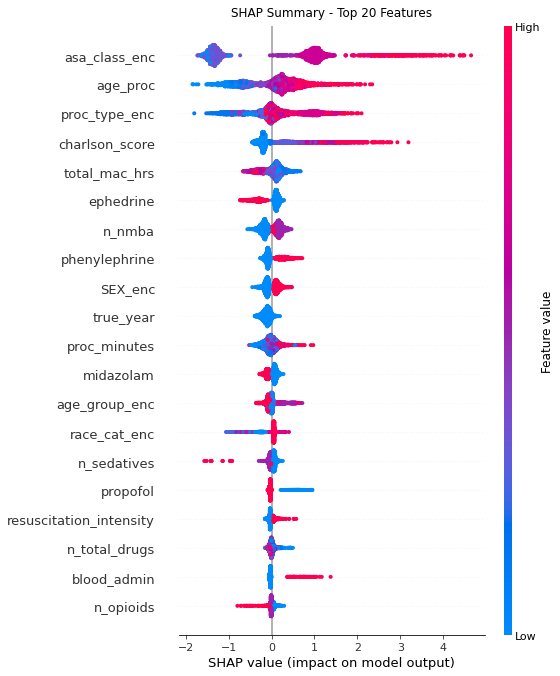

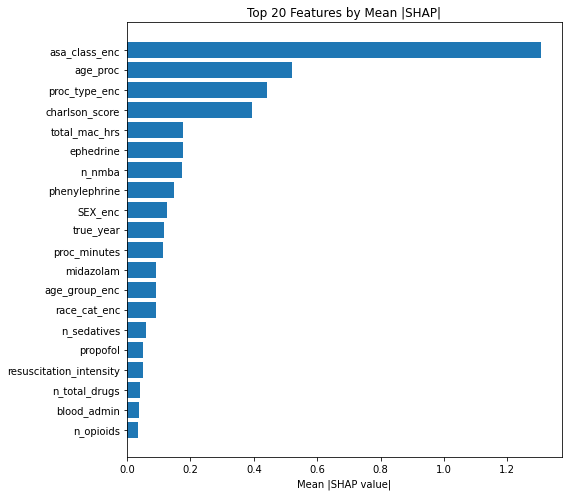

Top 10 features:


,Feature,Mean |SHAP|
14,asa_class_enc,1.306221
1,age_proc,0.521011
15,proc_type_enc,0.440291
4,charlson_score,0.395132
3,total_mac_hrs,0.177518
19,ephedrine,0.176243
7,n_nmba,0.173703
23,phenylephrine,0.147639
12,SEX_enc,0.126720
0,true_year,0.116124


Saved -> artifacts/shap_beeswarm.png, shap_bar.png, shap_importance.csv


In [14]:
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), min(3000, len(X_test)), replace=False)
X_shap   = X_test.iloc[shap_idx].values  # numpy array - avoids categorical mismatch

explainer   = shap.TreeExplainer(model)
shap_vals   = explainer.shap_values(X_shap)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

# Beeswarm
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=FINAL_FEAT, max_display=20, show=False)
plt.title('SHAP Summary - Top 20 Features', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('artifacts/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart
mean_shap = pd.DataFrame({
    'Feature':FINAL_FEAT,
    'Mean |SHAP|':np.abs(shap_vals).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8,7))
ax.barh(mean_shap['Feature'][::-1], mean_shap['Mean |SHAP|'][::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 Features by Mean |SHAP|')
plt.tight_layout()
plt.savefig('artifacts/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
display(mean_shap.head(10).round(6))
mean_shap.to_csv('artifacts/shap_importance.csv', index=False)
print('Saved -> artifacts/shap_beeswarm.png, shap_bar.png, shap_importance.csv')


## Step 7 — Decision Curve Analysis (Calibrated Predictions)

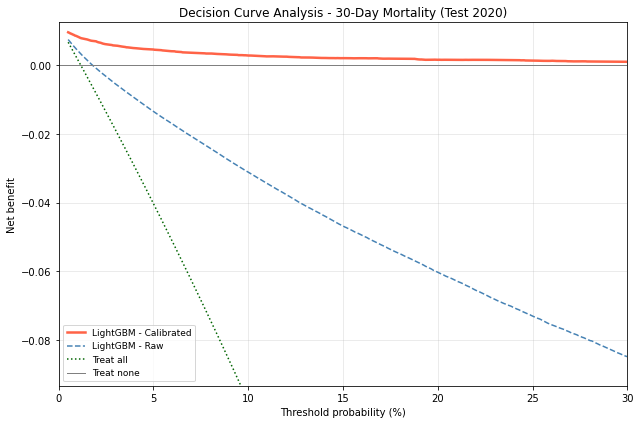

-- Net benefit at key thresholds (Test 2020, Calibrated) --


,Threshold (%),NB Calibrated,NB Raw,NB Treat all,NB Treat none
0,1.0,0.00846,0.00447,0.00199,0.0
1,2.0,0.00700,-0.00087,-0.00824,0.0
2,5.0,0.00462,-0.01341,-0.04024,0.0
3,10.0,0.00286,-0.03120,-0.09833,0.0
4,15.0,0.00209,-0.04678,-0.16248,0.0
5,20.0,0.00162,-0.06033,-0.23551,0.0
6,30.0,0.00104,-0.08492,-0.41185,0.0


Saved -> artifacts/decision_curve.png


In [15]:
def decision_curve(y_true, p_pred, thresholds):
    y = np.array(y_true, dtype=float)
    p = np.array(p_pred, dtype=float)
    n = len(y); prev = y.mean()
    nb_model, nb_all = [], []
    for t in thresholds:
        if t >= 1.0:
            nb_model.append(np.nan); nb_all.append(np.nan); continue
        tp = ((p >= t) & (y == 1)).sum()
        fp = ((p >= t) & (y == 0)).sum()
        nb_model.append((tp/n) - (fp/n) * (t/(1-t)))
        nb_all.append(prev - (1-prev) * (t/(1-t)))
    return np.array(nb_model), np.array(nb_all)

thresh = np.linspace(0.005, 0.30, 500)
nb_cal,  nb_all_cal  = decision_curve(y_test, p_test_cal,  thresh)
nb_raw,  nb_all_raw  = decision_curve(y_test, p_test_raw,  thresh)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresh*100, nb_cal,  linewidth=2.5, color='tomato',    label='LightGBM - Calibrated')
ax.plot(thresh*100, nb_raw,  linewidth=1.5, color='steelblue', linestyle='--', label='LightGBM - Raw')
ax.plot(thresh*100, nb_all_cal, linewidth=1.5, color='darkgreen', linestyle=':', label='Treat all')
ax.axhline(0, color='gray', linewidth=1.0, label='Treat none')
ax.set_xlim(0, 30)
y_min = min(np.nanmin(nb_cal), np.nanmin(nb_raw)) * 1.1
y_max = max(np.nanmax(nb_cal), np.nanmax(nb_raw)) * 1.3
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Threshold probability (%)'); ax.set_ylabel('Net benefit')
ax.set_title("Decision Curve Analysis - 30-Day Mortality (Test 2020)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/decision_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Net benefit table
dca_rows = []
for thr in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]:
    idx = np.argmin(np.abs(thresh - thr))
    dca_rows.append({'Threshold (%)':round(thr*100,1),
                     'NB Calibrated':round(float(nb_cal[idx]),5) if not np.isnan(nb_cal[idx]) else np.nan,
                     'NB Raw':round(float(nb_raw[idx]),5) if not np.isnan(nb_raw[idx]) else np.nan,
                     'NB Treat all':round(float(nb_all_cal[idx]),5) if not np.isnan(nb_all_cal[idx]) else np.nan,
                     'NB Treat none':0.0})
print('-- Net benefit at key thresholds (Test 2020, Calibrated) --')
display(pd.DataFrame(dca_rows))
print('Saved -> artifacts/decision_curve.png')


### Bootstrap CI on Net Benefit
Patient-level bootstrap, 500 resamples, at the same key thresholds.

In [16]:
dca_bootstrap_table = bootstrap_net_benefit(
    y_test.values, p_test_cal, [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30],
    test_df['study_id'].values, n_boot=500
)
dca_bootstrap_table.to_csv('artifacts/DecisionCurve_Bootstrap_CI.csv', index=False)
print('Net benefit with 95% bootstrap CI (calibrated predictions, Test 2020):')
display(dca_bootstrap_table.round(5))


Net benefit with 95% bootstrap CI (calibrated predictions, Test 2020):


,Threshold (%),NB mean,NB CI low,NB CI high
0,1.0,0.00837,0.00758,0.00917
1,2.0,0.00695,0.00617,0.00770
2,5.0,0.00463,0.00399,0.00535
3,10.0,0.00290,0.00232,0.00357
4,15.0,0.00211,0.00162,0.00263
5,20.0,0.00163,0.00122,0.00206
6,30.0,0.00105,0.00068,0.00144


## Step 8 — Subgroup Analysis (Test 2020, Calibrated Predictions)

-- Subgroup performance - Test 2020 (Calibrated) --


,Subgroup,N,Deaths,Mortality (%),AUROC,PR-AUC,Mean predicted (%)
0,Overall - Test 2020,57254,670,1.17,0.9225,0.2654,1.071
1,ASA 2,22827,10,0.04,0.5183,0.0006,0.039
2,ASA 3,26946,315,1.17,0.8242,0.0909,0.959
3,ASA 4,3128,296,9.46,0.7567,0.3145,9.884
4,ASA 5,72,47,65.28,0.7370,0.8545,47.938
5,Sex=F,30976,317,1.02,0.9217,0.2527,0.873
6,Sex=M,26259,353,1.34,0.9222,0.2791,1.305
7,Age lt50,18677,74,0.40,0.9468,0.3111,0.379
8,Age 50_64,17949,165,0.92,0.9193,0.2830,0.957
9,Age 65_74,12945,186,1.44,0.8920,0.2642,1.341


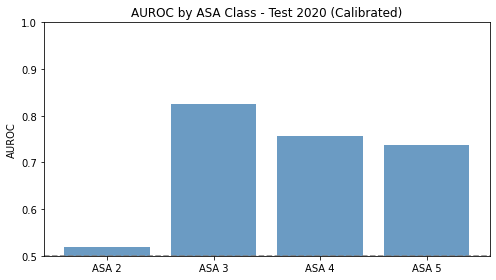

Saved -> artifacts/subgroup_performance_calibrated.csv


In [17]:
def subgroup(df_sub, p_sub, label):
    y = df_sub[TARGET].astype(int)
    if y.nunique() < 2 or len(y) < 50 or int(y.sum()) < 5:
        return None
    try:
        return {'Subgroup':label,'N':len(y),'Deaths':int(y.sum()),
                'Mortality (%)':round(100*y.mean(),2),
                'AUROC':round(roc_auc_score(y,p_sub),4),
                'PR-AUC':round(average_precision_score(y,p_sub),4),
                'Mean predicted (%)':round(100*np.array(p_sub).mean(),3)}
    except: return None

p_arr = p_test_cal  # use calibrated predictions throughout
results = []

r = subgroup(test_df, p_arr, 'Overall - Test 2020')
if r: results.append(r)

asa_map = {'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,
           '1E':1,'2E':2,'3E':3,'4E':4,'5E':5}
test_df['_asa_num'] = test_df['asa_class'].astype(str).map(asa_map)
for val in [1,2,3,4,5]:
    mask = test_df['_asa_num'] == val
    r = subgroup(test_df[mask], p_arr[mask.values], f'ASA {val}')
    if r: results.append(r)

for sex in test_df['SEX'].dropna().unique():
    mask = test_df['SEX'] == sex
    r = subgroup(test_df[mask], p_arr[mask.values], f'Sex={sex}')
    if r: results.append(r)

for grp in ['lt50','50_64','65_74','75_84','gte85']:
    mask = test_df['age_group'] == grp
    r = subgroup(test_df[mask], p_arr[mask.values], f'Age {grp}')
    if r: results.append(r)

for proc in test_df['proc_type'].value_counts().head(8).index:
    mask = test_df['proc_type'] == proc
    r = subgroup(test_df[mask], p_arr[mask.values], f'Proc: {proc}')
    if r: results.append(r)

subgroup_tbl = pd.DataFrame(results)
print('-- Subgroup performance - Test 2020 (Calibrated) --')
display(subgroup_tbl.round(4))
subgroup_tbl.to_csv('artifacts/subgroup_performance_calibrated.csv', index=False)

# Plot AUROC by ASA
asa_rows = subgroup_tbl[subgroup_tbl['Subgroup'].str.startswith('ASA')].copy()
if len(asa_rows) > 1:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(asa_rows['Subgroup'], asa_rows['AUROC'], color='steelblue', alpha=0.8)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.5, linestyle='--', color='gray')
    ax.set_ylabel('AUROC'); ax.set_title('AUROC by ASA Class - Test 2020 (Calibrated)')
    plt.tight_layout()
    plt.savefig('artifacts/subgroup_asa_auroc.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Saved -> artifacts/subgroup_performance_calibrated.csv')


### Bootstrap CIs for Subgroup AUROC/PR-AUC
Subgroup discrimination with uncertainty bounds. Subgroups under N=50 or fewer than 5 events are skipped.

In [18]:
subgroup_masks = [('Overall - Test 2020', pd.Series(True, index=test_df.index))]
for val in [1,2,3,4,5]:
    subgroup_masks.append((f'ASA {val}', test_df['_asa_num']==val))
for sex in test_df['SEX'].dropna().unique():
    subgroup_masks.append((f'Sex={sex}', test_df['SEX']==sex))
for grp in ['lt50','50_64','65_74','75_84','gte85']:
    subgroup_masks.append((f'Age {grp}', test_df['age_group']==grp))
for proc in test_df['proc_type'].value_counts().head(8).index:
    subgroup_masks.append((f'Proc: {proc}', test_df['proc_type']==proc))

subgroup_ci_rows = []
for label, mask in subgroup_masks:
    mask = mask.values if hasattr(mask, 'values') else np.asarray(mask)
    n, d = int(mask.sum()), int(y_test[mask].sum())
    if n < 50 or d < 5 or y_test[mask].nunique() < 2:
        continue
    res = bootstrap_performance(y_test[mask].values, p_arr[mask],
                                 test_df.loc[mask, 'study_id'].values, n_boot=500)
    res['Subgroup'] = label
    subgroup_ci_rows.append(res)

subgroup_bootstrap_table = pd.DataFrame(subgroup_ci_rows)[
    ['Subgroup','AUROC boot mean','AUROC CI low','AUROC CI high',
     'PR-AUC boot mean','PR-AUC CI low','PR-AUC CI high']]
subgroup_bootstrap_table.to_csv('artifacts/Subgroup_Bootstrap_CI.csv', index=False)
print('Subgroup performance with 95% bootstrap CI:')
display(subgroup_bootstrap_table.round(4))


Subgroup performance with 95% bootstrap CI:


,Subgroup,AUROC boot mean,AUROC CI low,AUROC CI high,PR-AUC boot mean,PR-AUC CI low,PR-AUC CI high
0,Overall - Test 2020,0.9230,0.9130,0.9328,0.2674,0.2340,0.3032
1,ASA 2,0.5178,0.3322,0.6930,0.0007,0.0002,0.0015
2,ASA 3,0.8239,0.8000,0.8451,0.0940,0.0657,0.1244
3,ASA 4,0.7570,0.7281,0.7867,0.3181,0.2662,0.3686
4,ASA 5,0.7350,0.6096,0.8436,0.8582,0.7556,0.9343
5,Sex=F,0.9211,0.9058,0.9343,0.2547,0.2079,0.3002
6,Sex=M,0.9225,0.9100,0.9340,0.2810,0.2336,0.3259
7,Age lt50,0.9465,0.9056,0.9738,0.3182,0.2179,0.4186
8,Age 50_64,0.9197,0.8957,0.9388,0.2853,0.2074,0.3663
9,Age 65_74,0.8920,0.8675,0.9140,0.2692,0.2066,0.3434


## Step 9 — Stratified Performance by Clinical Vulnerability Decile
Fits a clinical vulnerability model (ASA + age + Charlson) on training data, then evaluates the full LightGBM model within each vulnerability stratum on test 2020. Also serves as the floor-model comparator below.

In [19]:
from sklearn.linear_model import LogisticRegression as SimpleLR
from sklearn.preprocessing import StandardScaler

asa_map = {'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,
           '1E':1,'2E':2,'3E':3,'4E':4,'5E':5}

def asa_numeric(df):
    return df['asa_class'].astype(str).map(asa_map).fillna(3).astype(float)

train_V = pd.DataFrame({
    'asa': asa_numeric(train_df),
    'age': train_df['age_proc'].fillna(train_df['age_proc'].median()),
    'cci': train_df['charlson_score'].fillna(0),
})
test_V = pd.DataFrame({
    'asa': asa_numeric(test_df),
    'age': test_df['age_proc'].fillna(train_df['age_proc'].median()),
    'cci': test_df['charlson_score'].fillna(0),
})

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(train_V)
X_te_s = scaler.transform(test_V)

vuln_lr = SimpleLR(C=1.0, max_iter=1000, random_state=42)
vuln_lr.fit(X_tr_s, y_train)

p_vuln_train = vuln_lr.predict_proba(X_tr_s)[:, 1]
p_vuln_test  = vuln_lr.predict_proba(X_te_s)[:, 1]

edges = np.unique(np.quantile(p_vuln_train, np.linspace(0, 1, 11)))
edges[0] = -np.inf; edges[-1] = np.inf
dec_labels = [f'D{i}' for i in range(1, len(edges))]

test_df_s = test_df.copy()
test_df_s['vuln_decile'] = pd.cut(p_vuln_test, bins=edges,
                                   labels=dec_labels, include_lowest=True)

print(f'Vulnerability model AUROC (train): {roc_auc_score(y_train, p_vuln_train):.4f}')
print(f'Vulnerability model AUROC (test):  {roc_auc_score(y_test, p_vuln_test):.4f}')
print(f'\nDecile distribution (test 2020):')
print(test_df_s['vuln_decile'].value_counts().sort_index())


Vulnerability model AUROC (train): 0.9010
Vulnerability model AUROC (test):  0.9000

Decile distribution (test 2020):
vuln_decile
D1     3247
D2     4706
D3     4672
D4     5776
D5     7584
D6     5683
D7     5502
D8     6566
D9     7040
D10    6478
Name: count, dtype: int64


In [20]:
strat_rows = []
for dec in dec_labels:
    mask = (test_df_s['vuln_decile'] == dec).values
    y_d = y_test[mask]
    p_d = p_test_cal[mask]
    n, d = int(mask.sum()), int(y_d.sum())
    if n < 50 or d < 5 or y_d.nunique() < 2:
        strat_rows.append({'Decile':dec,'N':n,'Deaths':d,
                           'Mortality (%)':round(100*y_d.mean(),2) if n>0 else np.nan,
                           'AUROC':np.nan,'PR-AUC':np.nan,
                           'Mean predicted (%)':round(100*p_d.mean(),3) if n>0 else np.nan,
                           'Note':'Too few events'})
        continue
    strat_rows.append({
        'Decile':dec, 'N':n, 'Deaths':d,
        'Mortality (%)':round(100*y_d.mean(),2),
        'AUROC':round(roc_auc_score(y_d,p_d),4),
        'PR-AUC':round(average_precision_score(y_d,p_d),4),
        'Mean predicted (%)':round(100*p_d.mean(),3),
        'Note':''
    })

strat_df = pd.DataFrame(strat_rows)
print('-- Stratified performance by vulnerability decile (Test 2020, Calibrated) --')
display(strat_df)
strat_df.to_csv('artifacts/stratified_by_vulnerability_decile.csv', index=False)
print('Saved -> artifacts/stratified_by_vulnerability_decile.csv')


-- Stratified performance by vulnerability decile (Test 2020, Calibrated) --


,Decile,N,Deaths,Mortality (%),AUROC,PR-AUC,Mean predicted (%),Note
0,D1,3247,0,0.00,NaN,NaN,0.005,Too few events
1,D2,4706,1,0.02,NaN,NaN,0.013,Too few events
2,D3,4672,1,0.02,NaN,NaN,0.012,Too few events
3,D4,5776,1,0.02,NaN,NaN,0.031,Too few events
4,D5,7584,6,0.08,0.3826,0.0007,0.045,
5,D6,5683,10,0.18,0.7566,0.0115,0.186,
6,D7,5502,18,0.33,0.7825,0.0705,0.392,
7,D8,6566,47,0.72,0.7883,0.0925,0.610,
8,D9,7040,118,1.68,0.7011,0.0634,1.298,
9,D10,6478,468,7.22,0.7899,0.3466,6.842,


Saved -> artifacts/stratified_by_vulnerability_decile.csv


### Floor-Model Comparison: Bootstrap CI + NRI
Quantifies what the full LightGBM model adds beyond ASA + age + Charlson alone.

In [21]:
floor_perf = bootstrap_performance(y_test.values, p_vuln_test, test_df['study_id'].values, n_boot=1000)
full_perf  = bootstrap_performance(y_test.values, p_test_cal,  test_df['study_id'].values, n_boot=1000)

floor_vs_full_perf = pd.DataFrame([
    {'Model': 'Floor (ASA+age+CCI)', **floor_perf},
    {'Model': 'Full LightGBM (calibrated)', **full_perf},
])[['Model','AUROC boot mean','AUROC CI low','AUROC CI high',
    'PR-AUC boot mean','PR-AUC CI low','PR-AUC CI high',
    'Brier boot mean','Brier CI low','Brier CI high']]
floor_vs_full_perf.to_csv('artifacts/FloorModel_vs_Full_Performance.csv', index=False)

floor_vs_full_nri = net_reclassification_improvement(
    y_test.values, p_vuln_test, p_test_cal, thresholds=(0.01, 0.05))
floor_vs_full_nri_table = pd.DataFrame([floor_vs_full_nri])
floor_vs_full_nri_table.to_csv('artifacts/FloorModel_vs_Full_NRI.csv', index=False)

print('Floor model vs. full LightGBM - bootstrap-CI performance (Test 2020):')
display(floor_vs_full_perf.round(4))
print('\nNRI, full LightGBM vs. floor model (1%/5% mortality-risk categories):')
display(floor_vs_full_nri_table.round(4))


Floor model vs. full LightGBM - bootstrap-CI performance (Test 2020):


,Model,AUROC boot mean,AUROC CI low,AUROC CI high,PR-AUC boot mean,PR-AUC CI low,PR-AUC CI high,Brier boot mean,Brier CI low,Brier CI high
0,Floor (ASA+age+CCI),0.9001,0.8900,0.9099,0.1352,0.1119,0.1591,0.0109,0.0102,0.0117
1,Full LightGBM (calibrated),0.9228,0.9128,0.9322,0.2669,0.2331,0.3010,0.0099,0.0092,0.0106



NRI, full LightGBM vs. floor model (1%/5% mortality-risk categories):


,NRI events,NRI nonevents,NRI total,N events,N nonevents
0,-0.0179,0.2318,0.2139,670,56584


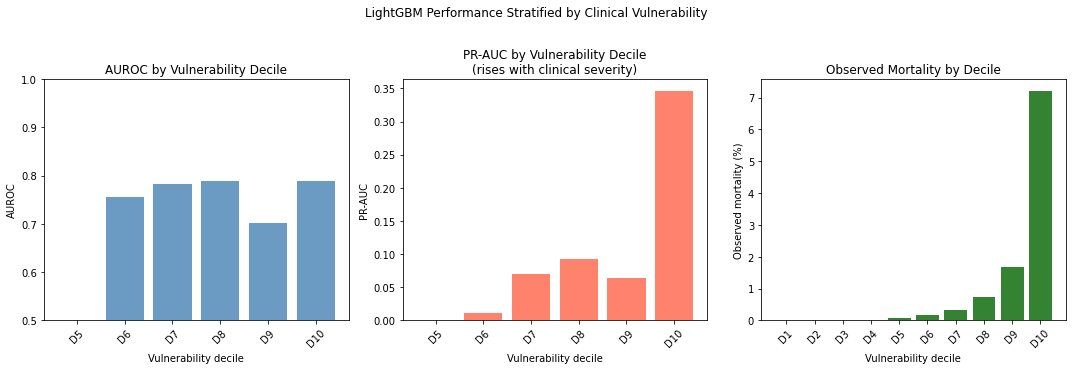

Saved -> artifacts/stratified_vulnerability_performance.png


In [22]:
# Plot AUROC and PR-AUC by vulnerability decile
valid = strat_df[strat_df['AUROC'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(valid['Decile'], valid['AUROC'], color='steelblue', alpha=0.8)
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.5, linestyle='--', color='gray', linewidth=1)
axes[0].set_xlabel('Vulnerability decile'); axes[0].set_ylabel('AUROC')
axes[0].set_title('AUROC by Vulnerability Decile')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(valid['Decile'], valid['PR-AUC'], color='tomato', alpha=0.8)
axes[1].set_xlabel('Vulnerability decile'); axes[1].set_ylabel('PR-AUC')
axes[1].set_title('PR-AUC by Vulnerability Decile\n(rises with clinical severity)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(strat_df['Decile'], strat_df['Mortality (%)'], color='darkgreen', alpha=0.8)
axes[2].set_xlabel('Vulnerability decile'); axes[2].set_ylabel('Observed mortality (%)')
axes[2].set_title('Observed Mortality by Decile')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle("LightGBM Performance Stratified by Clinical Vulnerability",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('artifacts/stratified_vulnerability_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> artifacts/stratified_vulnerability_performance.png')


## Final Summary

In [23]:
import os
print('='*65)
print("SINGLE FULL-FEATURE LIGHTGBM MODEL - SUMMARY")
print('='*65)
print(f'\nTrain: {len(train_df):,} (<=2018) | Val: {len(val_df):,} (2019) | Test: {len(test_df):,} (2020)')
print(f'\nTest 2020 - Raw model:')
print(f'  AUROC:  {roc_auc_score(y_test, p_test_raw):.4f}')
print(f'  PR-AUC: {average_precision_score(y_test, p_test_raw):.4f}')
print(f'  Brier:  {brier_score_loss(y_test, p_test_raw):.4f}')
print(f'\nTest 2020 - Calibrated model (Platt scaling):')
print(f'  AUROC:  {roc_auc_score(y_test, p_test_cal):.4f}  [bootstrap CI: {full_perf["AUROC CI low"]:.4f}, {full_perf["AUROC CI high"]:.4f}]')
print(f'  PR-AUC: {average_precision_score(y_test, p_test_cal):.4f}  [bootstrap CI: {full_perf["PR-AUC CI low"]:.4f}, {full_perf["PR-AUC CI high"]:.4f}]')
print(f'  Brier:  {brier_score_loss(y_test, p_test_cal):.4f}')

# Discrimination in the clinically actionable range, reported alongside the headline AUROC.
print(f'\nDiscrimination by ASA class and vulnerability decile:')
_asa_report = subgroup_tbl[subgroup_tbl['Subgroup'].isin(['ASA 2','ASA 3','ASA 4','ASA 5'])]
for _, _r in _asa_report.iterrows():
    print(f"  {_r['Subgroup']}: AUROC={_r['AUROC']:.2f} (N={_r['N']:,}, {_r['Deaths']} events)")
_d10_row = strat_df[strat_df['Decile']=='D10']
if len(_d10_row) and pd.notna(_d10_row['AUROC'].iloc[0]):
    print(f"  Vulnerability decile D10: AUROC={_d10_row['AUROC'].iloc[0]:.2f} "
          f"(N={_d10_row['N'].iloc[0]:,}, {_d10_row['Deaths'].iloc[0]} events)")
_asa2_auroc = subgroup_tbl.loc[subgroup_tbl['Subgroup']=='ASA 2', 'AUROC']
_asa2_auroc = float(_asa2_auroc.iloc[0]) if len(_asa2_auroc) else float('nan')
print(f'  ASA 2 AUROC: {_asa2_auroc:.2f} (N=10 events)')

# NRI by component (events vs. nonevents), not just the total.
print(f'\nNRI, full model vs. floor (ASA+age+CCI), by component:')
_nri_row = floor_vs_full_nri_table.iloc[0]
print(f"  NRI events (correctly reclassifying patients who died):     {_nri_row['NRI events']:.4f}")
print(f"  NRI nonevents (correctly reclassifying survivors):          {_nri_row['NRI nonevents']:.4f}")
print(f"  NRI total:                                                  {_nri_row['NRI total']:.4f}")

print('\nOutputs:')
for f in ['artifacts/lgbm_final.txt','artifacts/platt_scaler.joblib',
          'artifacts/performance_raw_vs_calibrated.csv','artifacts/Performance_Bootstrap_CI.csv',
          'artifacts/calibration_before_after.png',
          'artifacts/shap_beeswarm.png','artifacts/shap_bar.png','artifacts/shap_importance.csv',
          'artifacts/decision_curve.png','artifacts/DecisionCurve_Bootstrap_CI.csv',
          'artifacts/subgroup_performance_calibrated.csv','artifacts/Subgroup_Bootstrap_CI.csv',
          'artifacts/stratified_by_vulnerability_decile.csv',
          'artifacts/FloorModel_vs_Full_Performance.csv','artifacts/FloorModel_vs_Full_NRI.csv',
          'artifacts/Table1_Overall.csv','artifacts/Table1_ByCohort.csv','artifacts/Table1_ByVitalStatus.csv',
          'artifacts/CaseMixDrift_Train_vs_Test.csv','artifacts/CaseMixDrift_Train_vs_Val.csv',
          'artifacts/Missing_Data_Report.csv','artifacts/Cohort_Flow.csv',
          'artifacts/LightGBM_Hyperparameters.csv']:
    print(f'  {"OK " if os.path.exists(f) else "MISSING"}  {f}')


SINGLE FULL-FEATURE LIGHTGBM MODEL - SUMMARY

Train: 278,514 (<=2018) | Val: 52,117 (2019) | Test: 57,254 (2020)

Test 2020 - Raw model:
  AUROC:  0.9225
  PR-AUC: 0.2654
  Brier:  0.0921

Test 2020 - Calibrated model (Platt scaling):
  AUROC:  0.9225  [bootstrap CI: 0.9128, 0.9322]
  PR-AUC: 0.2654  [bootstrap CI: 0.2331, 0.3010]
  Brier:  0.0099

Discrimination by ASA class and vulnerability decile:
  ASA 2: AUROC=0.52 (N=22,827, 10 events)
  ASA 3: AUROC=0.82 (N=26,946, 315 events)
  ASA 4: AUROC=0.76 (N=3,128, 296 events)
  ASA 5: AUROC=0.74 (N=72, 47 events)
  Vulnerability decile D10: AUROC=0.79 (N=6,478, 468 events)
  ASA 2 AUROC: 0.52 (N=10 events)

NRI, full model vs. floor (ASA+age+CCI), by component:
  NRI events (correctly reclassifying patients who died):     -0.0179
  NRI nonevents (correctly reclassifying survivors):          0.2318
  NRI total:                                                  0.2139

Outputs:
  OK   artifacts/lgbm_final.txt
  OK   artifacts/platt_scaler